LABORATORIO DE CLASIFICACION MULTICLASE

* transaction_id -> Identificador único de la transacción. (Categórico/String)

* customer_id -> Identificador único del cliente que realizó la transacción. (Categórico/String)

* merchant_id -> Identificador único del comercio donde se realizó la transacción. (Categórico/String)

* timestamp -> Fecha y hora exacta de la transacción. (Fecha/Hora)

* hour -> Hora del día en que ocurrió la transacción. (Numérico/Entero)

* day -> Día correspondiente a la transacción. (Numérico/Entero)

* weekday -> Día de la semana en que ocurrió la transacción. (Numérico/Entero)

* is_weekend -> Indica si la transacción ocurrió en fin de semana. (Binario 0/1)

* is_night -> Indica si la transacción ocurrió durante la noche. (Binario 0/1)

* customer_segment -> Segmento o tipo de cliente como regular, premium o vip. (Categórico/String)

* avg_spend_profile -> Promedio histórico de gasto del cliente. (Numérico/Decimal)

* home_lat -> Latitud de la ubicación del hogar del cliente. (Numérico/Decimal)

* home_lon -> Longitud de la ubicación del hogar del cliente. (Numérico/Decimal)

* past_fraud_history -> Indica si el cliente tiene historial previo de fraude. (Binario 0/1)

* credit_score -> Puntaje crediticio del cliente. (Numérico/Entero)

* account_age_days -> Antigüedad de la cuenta del cliente en días. (Numérico/Entero)

* merchant_category -> Categoría del comercio como retail, food, electronics, crypto, etc. (Categórico/String)

* merchant_risk_score -> Puntaje de riesgo asociado al comercio. (Numérico/Decimal)

* merchant_lat -> Latitud de la ubicación del comercio. (Numérico/Decimal)

* merchant_lon -> Longitud de la ubicación del comercio. (Numérico/Decimal)

* transaction_amount -> Monto de dinero de la transacción. (Numérico/Decimal)

* txn_lat -> Latitud desde donde se realizó la transacción. (Numérico/Decimal)

* txn_lon -> Longitud desde donde se realizó la transacción. (Numérico/Decimal)

* distance_from_home_km -> Distancia en kilómetros entre el hogar del cliente y la ubicación de la transacción. (Numérico/Decimal)

* is_foreign -> Indica si la transacción fue realizada en el extranjero. (Binario 0/1)

* high_risk_country -> Indica si la transacción ocurrió en un país considerado de alto riesgo. (Binario 0/1)

* device_type -> Tipo de dispositivo utilizado como móvil, tablet, desktop, etc. (Categórico/String)

* channel -> Canal utilizado para la transacción como online, POS, mobile_app, etc. (Categórico/String)

* is_new_device -> Indica si el dispositivo utilizado es nuevo para el cliente. (Binario 0/1)

* vpn_detected -> Indica si se detectó el uso de VPN durante la transacción. (Binario 0/1)

* tor_detected -> Indica si se detectó el uso de la red TOR. (Binario 0/1)

* device_id -> Identificador único del dispositivo utilizado. (Categórico/String)

* transaction_velocity_1h -> Cantidad de transacciones realizadas en la última hora. (Numérico/Entero)

* transaction_velocity_24h -> Cantidad de transacciones realizadas en las últimas 24 horas. (Numérico/Entero)

* transaction_velocity_7d -> Cantidad de transacciones realizadas en los últimos 7 días. (Numérico/Entero)

* seconds_since_last_txn -> Segundos transcurridos desde la última transacción. (Numérico/Decimal)

* avg_amount_30d -> Promedio de montos transaccionados en los últimos 30 días. (Numérico/Decimal)

* amount_deviation_ratio -> Relación de desviación entre el monto actual y el promedio histórico del cliente. (Numérico/Decimal)

* merchant_ring_id -> Identificador de un grupo o red de comercios relacionados. (Categórico/String)

* shared_device_count -> Cantidad de usuarios que comparten el mismo dispositivo. (Numérico/Entero)

* customer_merchant_txn_count -> Cantidad de transacciones realizadas entre el cliente y el mismo comercio. (Numérico/Entero)

* label -> Etiqueta que indica si la transacción es fraudulenta o legítima. (Binario 0/1)

* fraud_type -> Tipo de fraude detectado como identity_theft, synthetic_fraud, account_takeover, etc. (Categórico/String)

* financial_loss -> Pérdida financiera ocasionada por el fraude. (Numérico/Decimal)

In [37]:
#from google.colab import drive
#drive.mount('/content/drive')

In [38]:
# se utiliza para el manejo de rutas y directorios.
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot

In [39]:
# df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/machine learning/datasetslabs/enterprise_fraud_dataset.csv', delimiter=',')
df = pd.read_csv('enterprise_fraud_dataset.csv', delimiter=',')
df.head()

,transaction_id,customer_id,merchant_id,timestamp,hour,day,weekday,is_weekend,is_night,customer_segment,...,transaction_velocity_7d,seconds_since_last_txn,avg_amount_30d,amount_deviation_ratio,merchant_ring_id,shared_device_count,customer_merchant_txn_count,label,fraud_type,financial_loss
0,TXN00036139,9802,1487,2025-01-22 14:02:41.154565663,14,22,2,0,0,regular,...,20,5.035833e+05,426.455356,0.9937,-1,0,4,0,legit,0.0
1,TXN00080533,9762,1412,2025-02-18 01:53:25.069276265,1,49,1,0,1,regular,...,16,1.607163e+06,298.932645,0.2719,-1,0,1,0,legit,0.0
2,TXN00104222,9230,1690,2025-03-04 00:29:01.950036691,0,63,1,0,1,regular,...,17,1.702030e+05,502.709227,0.6882,-1,2,1,0,legit,0.0
3,TXN00154470,6009,942,2025-04-02 21:41:53.035782236,21,92,2,0,0,regular,...,17,1.076657e+04,320.324984,0.8116,13,0,3,0,legit,0.0
4,TXN00079799,2818,715,2025-02-17 14:30:54.154685560,14,48,0,0,0,regular,...,14,2.087674e+06,183.407743,0.7762,13,1,4,0,legit,0.0


## **COLUMNA CUSTOMER_SEGMENT QUE ES TEXTO A NUMERO**

In [40]:
# Verificar si existen valores nulos
if df['customer_segment'].isnull().any():
    print("La columna contiene valores nulos")
else:
    print("La columna no contiene valores nulos")

La columna no contiene valores nulos


In [41]:
# Contar registros por categoría
agrupadas = df['customer_segment'].value_counts()

print(agrupadas)

customer_segment
regular    111267
new         38876
premium     30181
dormant     19676
Name: count, dtype: int64


In [42]:
print(df['customer_segment'].unique())

<StringArray>
['regular', 'new', 'dormant', 'premium']
Length: 4, dtype: str


In [43]:
# Lista de tus 133 categorías únicas
lista_clientes = ['regular', 'new', 'dormant', 'premium']

# Creamos un diccionario donde cada protocolo tiene un ID (ej: 'tcp': 0, 'udp': 1...)
proto_to_numeric = {proto: index for index, proto in enumerate(lista_clientes, start=1)}

# Aplicamos el mapeo al DataFrame
df['customer_segment_num'] = df['customer_segment'].map(proto_to_numeric)

## **COLUMNA MERCHANT_CATEGORY QUE ES TEXTO A NUMERO**

In [44]:
# Verificar si existen valores nulos
if df['merchant_category'].isnull().any():
    print("La columna contiene valores nulos")
else:
    print("La columna no contiene valores nulos")

La columna no contiene valores nulos


In [45]:
# Contar registros por categoría
agrupadas = df['merchant_category'].value_counts()

print(agrupadas)

merchant_category
food           38940
retail         38512
grocery        32765
electronics    30017
travel         20597
luxury         17678
gambling       10988
crypto         10503
Name: count, dtype: int64


In [46]:
print(df['merchant_category'].unique())

<StringArray>
['electronics',        'food',     'grocery',      'crypto',      'retail',
      'luxury',      'travel',    'gambling']
Length: 8, dtype: str


In [47]:
# Lista de tus 133 categorías únicas
lista_clientes = ['electronics', 'food', 'grocery', 'crypto', 'retail', 'luxury', 'travel', 'gambling']

# Creamos un diccionario donde cada protocolo tiene un ID (ej: 'tcp': 0, 'udp': 1...)
proto_to_numeric = {proto: index for index, proto in enumerate(lista_clientes, start=1)}

# Aplicamos el mapeo al DataFrame
df['merchant_category_num'] = df['merchant_category'].map(proto_to_numeric)

## **COLUMNA DEVICE_TYPE QUE ES TEXTO A NUMERO**

In [48]:
# Verificar si existen valores nulos
if df['device_type'].isnull().any():
    print("La columna contiene valores nulos")
else:
    print("La columna no contiene valores nulos")

La columna no contiene valores nulos


In [49]:
# Contar registros por categoría
agrupadas = df['device_type'].value_counts()

print(agrupadas)

device_type
mobile_ios         60397
mobile_android     55778
desktop_chrome     36133
desktop_firefox    15992
tablet_ios         13773
tablet_android     11945
unknown             5982
Name: count, dtype: int64


In [50]:
print(df['device_type'].unique())

<StringArray>
[ 'mobile_android',         'unknown',      'mobile_ios',  'tablet_android',
 'desktop_firefox',  'desktop_chrome',      'tablet_ios']
Length: 7, dtype: str


In [51]:
# Lista de tus 133 categorías únicas
lista_clientes = ['mobile_android', 'unknown', 'mobile_ios', 'tablet_android', 'desktop_firefox', 'desktop_chrome', 'tablet_ios']

# Creamos un diccionario donde cada protocolo tiene un ID (ej: 'tcp': 0, 'udp': 1...)
proto_to_numeric = {proto: index for index, proto in enumerate(lista_clientes, start=1)}

# Aplicamos el mapeo al DataFrame
df['device_type_num'] = df['device_type'].map(proto_to_numeric)

## **COLUMNA CHANNEL QUE ES TEXTO A NUMERO**

In [52]:
# Verificar si existen valores nulos
if df['channel'].isnull().any():
    print("La columna contiene valores nulos")
else:
    print("La columna no contiene valores nulos")

La columna no contiene valores nulos


In [53]:
# Contar registros por categoría
agrupadas = df['channel'].value_counts()

print(agrupadas)

channel
online    79882
pos       70326
in_app    29706
atm       20086
Name: count, dtype: int64


In [54]:
print(df['channel'].unique())

<StringArray>
['pos', 'atm', 'online', 'in_app']
Length: 4, dtype: str


In [55]:
# Lista de tus 133 categorías únicas
lista_clientes = ['pos', 'atm', 'online', 'in_app']

# Creamos un diccionario donde cada protocolo tiene un ID (ej: 'tcp': 0, 'udp': 1...)
proto_to_numeric = {proto: index for index, proto in enumerate(lista_clientes, start=1)}

# Aplicamos el mapeo al DataFrame
df['channel_num'] = df['channel'].map(proto_to_numeric)

## **COLUMNA FRAUD_TYPE QUE ES TEXTO A NUMERO COLUMNA DE Y PREDICHA**

In [56]:
# Verificar si existen valores nulos
if df['fraud_type'].isnull().any():
    print("La columna contiene valores nulos")
else:
    print("La columna no contiene valores nulos")

La columna no contiene valores nulos


In [57]:
# Contar registros por categoría
agrupadas = df['fraud_type'].value_counts()

print(agrupadas)

fraud_type
legit                 194437
identity_theft          2065
account_takeover        1260
card_testing             977
fraud_ring               776
synthetic_identity       485
Name: count, dtype: int64


In [58]:
print(df['fraud_type'].unique())

<StringArray>
[             'legit',     'identity_theft',         'fraud_ring',
   'account_takeover',       'card_testing', 'synthetic_identity']
Length: 6, dtype: str


In [59]:
# Lista de tus 133 categorías únicas
lista_fraudes = ['legit', 'identity_theft', 'fraud_ring', 'account_takeover', 'card_testing', 'synthetic_identity']

# Creamos un diccionario donde cada protocolo tiene un ID (ej: 'tcp': 0, 'udp': 1...)
proto_to_numeric = {proto: index for index, proto in enumerate(lista_fraudes, start=0)}

# Aplicamos el mapeo al DataFrame
df['fraud_type_num'] = df['fraud_type'].map(proto_to_numeric)

print('======= MAPEO DE FRAUDES A NÚMEROS ======')

for categoria, valor in proto_to_numeric.items():
    print(f"{categoria} -> {valor}")

======= MAPEO DE FRAUDES A NÚMEROS ======
legit -> 0
identity_theft -> 1
fraud_ring -> 2
account_takeover -> 3
card_testing -> 4
synthetic_identity -> 5


In [60]:
df

,transaction_id,customer_id,merchant_id,timestamp,hour,day,weekday,is_weekend,is_night,customer_segment,...,shared_device_count,customer_merchant_txn_count,label,fraud_type,financial_loss,customer_segment_num,merchant_category_num,device_type_num,channel_num,fraud_type_num
0,TXN00036139,9802,1487,2025-01-22 14:02:41.154565663,14,22,2,0,0,regular,...,0,4,0,legit,0.0,1,1,1,1,0
1,TXN00080533,9762,1412,2025-02-18 01:53:25.069276265,1,49,1,0,1,regular,...,0,1,0,legit,0.0,1,2,2,2,0
2,TXN00104222,9230,1690,2025-03-04 00:29:01.950036691,0,63,1,0,1,regular,...,2,1,0,legit,0.0,1,3,1,3,0
3,TXN00154470,6009,942,2025-04-02 21:41:53.035782236,21,92,2,0,0,regular,...,0,3,0,legit,0.0,1,4,3,2,0
4,TXN00079799,2818,715,2025-02-17 14:30:54.154685560,14,48,0,0,0,regular,...,1,4,0,legit,0.0,1,5,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,TXN00057042,10625,1652,2025-02-04 00:57:39.212327989,0,35,1,0,1,regular,...,0,2,0,legit,0.0,1,2,7,4,0
199996,TXN00167080,1975,750,2025-04-10 11:24:24.500505749,11,100,3,0,0,regular,...,0,4,0,legit,0.0,1,5,6,3,0
199997,TXN00177337,5139,1591,2025-04-16 13:21:58.135764942,13,106,2,0,0,regular,...,0,2,0,legit,0.0,1,2,5,3,0
199998,TXN00023587,11129,1588,2025-01-15 02:59:47.294468908,2,15,2,0,1,regular,...,0,1,0,legit,0.0,1,2,3,2,0


In [61]:
X = df.drop(['transaction_id', 'customer_id', 'merchant_id', 'timestamp', 'home_lat', 'home_lon',
    'merchant_lat', 'merchant_lon', 'txn_lat', 'txn_lon', 'device_id', 'label', 'financial_loss', 
    'fraud_type', 'customer_segment', 'merchant_category', 'device_type', 'channel', 'fraud_type_num'], axis=1)
y = df['fraud_type_num']
X.head()

,hour,day,weekday,is_weekend,is_night,avg_spend_profile,past_fraud_history,credit_score,account_age_days,merchant_risk_score,...,seconds_since_last_txn,avg_amount_30d,amount_deviation_ratio,merchant_ring_id,shared_device_count,customer_merchant_txn_count,customer_segment_num,merchant_category_num,device_type_num,channel_num
0,14,22,2,0,0,363.036636,0,528,698,0.258955,...,5.035833e+05,426.455356,0.9937,-1,0,4,1,1,1,1
1,1,49,1,0,1,341.886263,0,512,1604,0.168165,...,1.607163e+06,298.932645,0.2719,-1,0,1,1,2,2,2
2,0,63,1,0,1,606.779907,0,739,2244,0.173804,...,1.702030e+05,502.709227,0.6882,-1,2,1,1,3,1,3
3,21,92,2,0,0,317.343699,0,615,1790,0.578059,...,1.076657e+04,320.324984,0.8116,13,0,3,1,4,3,2
4,14,48,0,0,0,168.961693,0,676,1872,0.171036,...,2.087674e+06,183.407743,0.7762,13,1,4,1,5,4,2


## **Separar 80% de entrenamiento y 20% de prueba**

In [62]:
from sklearn.model_selection import train_test_split
# Separar entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=15
)

### **Definicion de la Funcion de Normalizacion**

In [63]:
def normalizarCaracteristicas(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

### Normalizacion del Entrenamiento

In [64]:
# llama featureNormalize con los datos cargados
X_train_norm, mu, sigma = normalizarCaracteristicas(X_train)
print('Media calculada:')
print(mu)
print('==============================================')
print('Desviación estandar calculada:')
print(sigma)
print('==============================================')
print(X_train_norm)

Media calculada:
hour                               11.493594
day                                60.029625
weekday                             3.003213
is_weekend                          0.286894
is_night                            0.251962
avg_spend_profile                 302.334927
past_fraud_history                  0.075606
credit_score                      650.357425
account_age_days                 1995.382994
merchant_risk_score                 0.215099
transaction_amount                359.352454
distance_from_home_km             282.046041
is_foreign                          0.364638
high_risk_country                   0.077325
is_new_device                       0.131625
vpn_detected                        0.052581
tor_detected                        0.010750
transaction_velocity_1h             1.300812
transaction_velocity_24h            4.665106
transaction_velocity_7d            18.004675
seconds_since_last_txn         545278.778088
avg_amount_30d                    302.

### Normalizacion de la Prueba

In [65]:
X_test_norm = (X_test - mu) / sigma
print('Datos de prueba normalizados:')
print(X_test_norm)

Datos de prueba normalizados:
            hour       day   weekday  is_weekend  is_night  avg_spend_profile  \
174310 -0.936699  0.931258 -0.500991   -0.634284  1.723034           0.077796   
100957  0.361548 -0.088249 -0.500991   -0.634284 -0.580372           1.368453   
111897 -1.225199  1.193417  0.497783   -0.634284  1.723034           1.347332   
35829  -0.648200  1.484705 -1.499765   -0.634284 -0.580372           0.012345   
93286  -1.080949 -1.399044  1.496557    1.576582  1.723034          -1.139696   
...          ...       ...       ...         ...       ...                ...   
41160   0.073049 -1.078628 -0.001604   -0.634284 -0.580372          -0.372337   
82500   1.082797  1.513833 -1.000378   -0.634284 -0.580372           1.316569   
179115 -1.369449 -1.166014 -1.499765   -0.634284  1.723034          -0.591899   
122645  1.515547  0.989515  0.497783   -0.634284 -0.580372           1.642351   
122717 -1.657948  1.339061 -0.500991   -0.634284  1.723034          -0.193372  

In [66]:
m, n = X_train_norm.shape
print('Número de ejemplos de entrenamiento: ', m)
print('Número de características: ', n)

Número de ejemplos de entrenamiento:  160000
Número de características:  30


### Definimos funciones como Sigmoide, calcularCosto, descensoGradiente

In [67]:
def sigmoid(z):
    """
    Calcula la sigmoide de z.
    """
    return 1.0 / (1.0 + np.exp(-z))

In [68]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [69]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

### Definimos OneVsAll

In [70]:
def OneVsAll(X, y, num_labels, lambda_):
  alpha = 0.001
  num_iters = 20000

  m, n = X.shape
  all_theta = np.zeros((num_labels, n + 1))

  # Agrega unos a la matriz X
  X = np.concatenate([np.ones((m, 1)), X], axis=1)

  for c in np.arange(num_labels):
      initial_theta = np.zeros(n + 1)

      y_actual = np.where(y == c, 1, 0)

      theta, J_history = descensoGradiente(initial_theta, X, y_actual, alpha, num_iters)

      all_theta[c] = theta
      # Grafica la convergencia del costo
      pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
      pyplot.xlabel('Numero de iteraciones')
      pyplot.ylabel('Costo J')

  return all_theta

### Entrenamiento

In [71]:
lambda_ = 0.1
num_labels = len(np.unique(y))
print('Número de etiquetas únicas: ', num_labels)

Número de etiquetas únicas:  6


(6, 31)


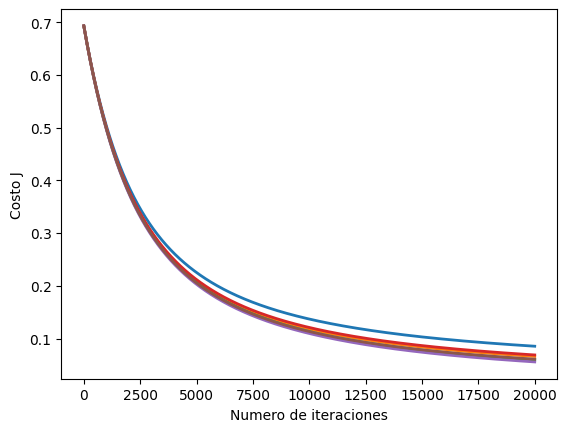

In [72]:
all_theta = OneVsAll(X_train_norm, y_train, num_labels, lambda_)
print(all_theta.shape)

In [78]:
print(all_theta)

[[ 2.73387006e+00 -6.14719199e-03 -3.88253185e-02  2.62051634e-04
  -1.33215237e-03  1.21608978e-02  5.24044680e-02  2.32074946e-03
   5.68875474e-03  1.11721224e-01 -1.30679838e-03 -1.27590036e-01
  -3.00273239e-01  2.11691351e-02 -7.55090135e-02 -1.73735560e-01
  -1.06683843e-01 -5.52089655e-02 -3.06581362e-01 -2.34862540e-01
   3.86005820e-03  4.08067763e-02  3.72011265e-02 -3.26524407e-01
   2.26950647e-03 -2.29123751e-01  1.81304869e-03  3.40135622e-03
   3.30693315e-03 -3.28667953e-03 -2.93837362e-03]
 [-2.83170633e+00  1.43201502e-03  4.16280423e-02  1.14675346e-03
   1.51931175e-03 -1.25378315e-03 -2.42493975e-02  3.47070765e-03
   2.71445683e-03  9.65247203e-03 -3.38409334e-03  6.99058370e-02
   3.58870726e-01 -1.69359837e-02  1.00330621e-01  6.53237010e-02
  -1.13709293e-02 -6.78392933e-03  4.61722729e-02 -5.42409079e-03
   3.68152394e-05  6.82714749e-03 -1.72758575e-02  1.67733146e-01
   5.70677790e-04 -9.11604218e-03 -8.19199697e-04 -1.61077410e-03
  -6.73873197e-04  1.2564

### Evaluacion

In [79]:
def predictOneVsAll(all_theta, X):
    """
    Devuelve un vector de predicciones para cada ejemplo en la matriz X.
    Tenga en cuenta que X contiene los ejemplos en filas.
    all_theta es una matriz donde la i-ésima fila es un vector theta de regresión logística entrenada para la i-ésima clase.
    Debe establecer p en un vector de valores de 0..K-1 (por ejemplo, p = [0, 2, 0, 1]
    predice clases 0, 2, 0, 1 para 4 ejemplos).

    Parametros
    ----------
    all_theta : array_like
        The trained parameters for logistic regression for each class.
        This is a matrix of shape (K x n+1) where K is number of classes
        and n is number of features without the bias.

    X : array_like
        Data points to predict their labels. This is a matrix of shape
        (m x n) where m is number of data points to predict, and n is number
        of features without the bias term. Note we add the bias term for X in
        this function.

    Devuelve
    -------
    p : array_like
        The predictions for each data point in X. This is a vector of shape (m, ).
    """

    m = X.shape[0];
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    # Add ones to the X data matrix
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis = 1)

    return p

In [80]:
y_test.value_counts()

fraud_type_num
0    38929
1      405
3      226
4      195
2      154
5       91
Name: count, dtype: int64

In [82]:
print(X_test_norm.shape)
pred = predictOneVsAll(all_theta, X_test_norm)
print('Precision del conjuto de entrenamiento: {:.2f}%'.format(np.mean(pred == y_test) * 100))
XPrueba = X_test_norm.iloc[0:45, :].copy()
print(XPrueba.shape)
#print(np.ones((1)))
#print(XPrueba)
#p = np.zeros(1)
XPrueba = np.concatenate([np.ones((45, 1)), XPrueba], axis=1)
print(XPrueba.shape)
p = np.argmax(sigmoid(XPrueba.dot(all_theta.T)), axis = 1)
print(p)

# displayData(X[1002:1003, :])
print(y_test.iloc[0:45])

(40000, 30)
Precision del conjuto de entrenamiento: 98.69%
(45, 30)
(45, 31)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0]
174310    0
100957    0
111897    0
35829     0
93286     0
155236    0
192718    0
51945     0
125423    0
56003     0
34654     0
130601    0
56402     0
26392     0
108044    0
83565     0
7378      0
145548    0
125200    0
18103     0
13012     0
146332    0
110321    0
14525     0
75225     0
83773     0
33910     0
49267     0
117437    0
172504    0
102237    0
126869    0
189285    2
53819     0
94781     0
13938     0
197964    0
152628    0
90652     0
43066     0
59670     0
5994      0
160255    0
54535     0
110979    0
Name: fraud_type_num, dtype: int64


In [76]:
numeric_to_label = {
    0: 'legit',
    1: 'identity_theft',
    2: 'fraud_ring',
    3: 'account_takeover',
    4: 'card_testing',
    5: 'synthetic_identity'
}

for i in range(10):

    label = predictOneVsAll(all_theta, X_test_norm.iloc[[i]])

    real_label = y_test.iloc[i]

    pred_num = label[0]

    pred_text = numeric_to_label[pred_num]

    print(f'Predicción {i+1}')
    print(f'Label real: {real_label}')
    print(f'Label predecido: {pred_text}')
    print('-----------------------------')

Predicción 1
Label real: 0
Label predecido: legit
-----------------------------
Predicción 2
Label real: 0
Label predecido: legit
-----------------------------
Predicción 3
Label real: 0
Label predecido: legit
-----------------------------
Predicción 4
Label real: 0
Label predecido: legit
-----------------------------
Predicción 5
Label real: 0
Label predecido: legit
-----------------------------
Predicción 6
Label real: 0
Label predecido: legit
-----------------------------
Predicción 7
Label real: 0
Label predecido: legit
-----------------------------
Predicción 8
Label real: 0
Label predecido: legit
-----------------------------
Predicción 9
Label real: 0
Label predecido: legit
-----------------------------
Predicción 10
Label real: 0
Label predecido: legit
-----------------------------
